In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import uniform
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/results/outputs/Group Pipeline (One-Hot).csv')

In [10]:
# 3. DEFINE X (FEATURES) AND y (TARGET)
y = df['Sales']
X = df.drop(['Sales', 'Game Title','Game Quality'], axis=1)

In [11]:
# 4. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (12524, 130)
Test set shape: (3132, 130)


In [12]:
# 5. HYPERPARAMETER TUNING
print("\nStarting Hyperparameter Tuning for Lasso...")
# We tune 'alpha', which controls the strength of regularization
param_dist = {'alpha': uniform(0.0001, 0.1)} # Search for alpha between 0.0001 and 0.1

lasso = Lasso(random_state=42)
random_search = RandomizedSearchCV(
    lasso, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_squared_error' # Use MSE for optimization
)
random_search.fit(X_train, y_train)

# Get the best model
best_lasso = random_search.best_estimator_
print(f"Best alpha found: {random_search.best_params_['alpha']:.6f}")


Starting Hyperparameter Tuning for Lasso...


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/19/cqkm18w51tl4rhq4kbfn42vh0000gn/T/joblib_memmapping_folder_69076_082d65c2158c40ecbafdf81c16dbd534_21daeca515a94555a1c30e22ae267d92 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/19/cqkm18w51tl4rhq4kbfn42vh0000gn/T/joblib_memmapping_folder_69076_02fdfa221dcb4de79e3ace2fbc5f3762_fc0581bd12504e1a981b5177198336e1 for automatic cleanup: unk

Best alpha found: 0.002158


In [13]:
# 6. MAKE PREDICTIONS AND EVALUATE
y_pred = best_lasso.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Tuned Lasso Regression Final Results ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("--------------------------------------------")


--- Tuned Lasso Regression Final Results ---
R-squared (R²): 0.9673
Mean Absolute Error (MAE): 0.0270
Root Mean Squared Error (RMSE): 0.0423
--------------------------------------------


In [14]:
# 7. ANALYSIS: FEATURE SELECTION
# Check how many features Lasso set to zero
total_features = X_train.shape[1]
zeroed_features = np.sum(best_lasso.coef_ == 0)
print(f"Lasso set {zeroed_features} out of {total_features} features to zero.")

Lasso set 123 out of 130 features to zero.


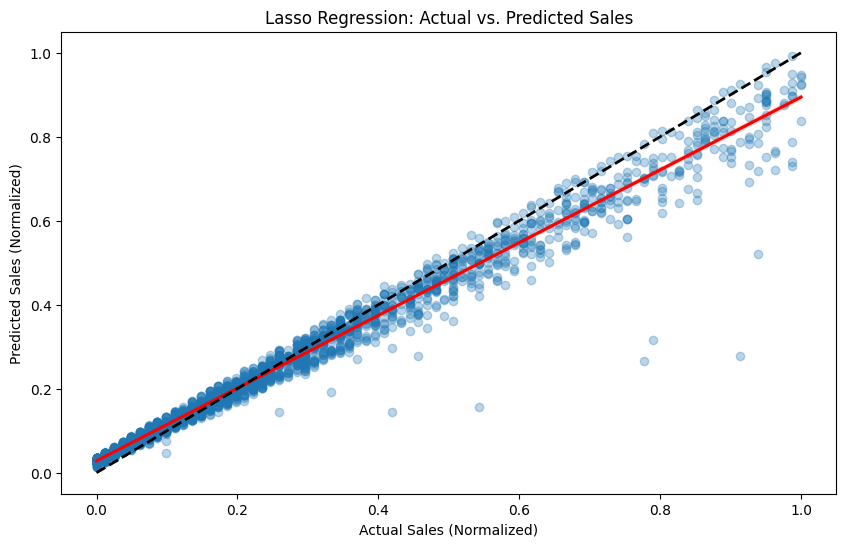

In [15]:
# 8. VISUALIZATION: ACTUAL VS. PREDICTED
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Lasso Regression: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales (Normalized)')
plt.ylabel('Predicted Sales (Normalized)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()